In [49]:
import inspect
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from typing import Callable

# Função objetivo 1

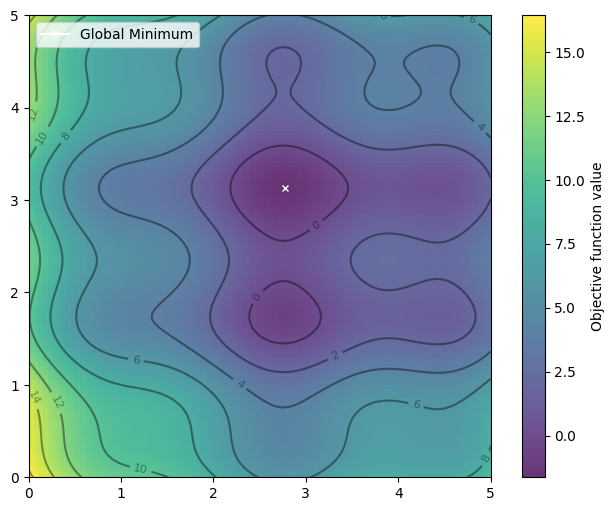

In [31]:
def f_1(x: NDArray|float, y: NDArray|float) -> NDArray|float:
    return (x-3.14)**2 + (y-2.72)**2 + np.cos(3*x+1.41) + np.sin(4*y-1.73)


x, y = np.array(np.meshgrid(np.linspace(0,5,100), np.linspace(0,5,100)))
z = f_1(x, y)
x_min = x.ravel()[np.argmin(z)]
y_min = y.ravel()[np.argmin(z)]

plt.figure(figsize=(8,6))
plt.imshow(z, extent=(0,5,0,5), origin='lower', cmap='viridis', alpha=0.8)
plt.colorbar(label='Objective function value')
plt.plot([x_min], [y_min], marker='x', markersize=5, color="white", label='Global Minimum')
contours = plt.contour(x, y, z, 10, colors='black', alpha=0.4)
plt.clabel(contours, inline=True, fontsize=8, fmt="%.0f")
plt.legend()
plt.show()

# Função Objetivo 2

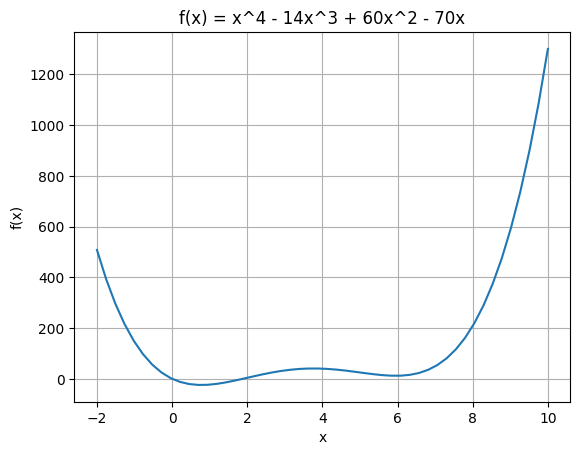

In [32]:
def f_2(x: NDArray[np.float64] | float) -> NDArray[np.float64] | float:
    return x**4 - 14 * x**3 + 60 * x**2 - 70 * x


xs = np.linspace(-2, 10, 50) # gera um array de 50 pontos entre -1 e 10
ys = f_2(xs)

plt.plot(xs, ys)
plt.title("f(x) = x^4 - 14x^3 + 60x^2 - 70x")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

In [195]:
class Star:
    def __init__(self, func: Callable[..., float]) -> None:
        self.func = func
        self.dim = len(inspect.signature(func).parameters)
        self.position = (np.random.rand(self.dim) - 0.5) * 1000
        self.fitness = self.evaluate()

    def evaluate(self) -> float:
        return float(self.func(*self.position))

    def move_towards(self, target: 'Star') -> None:
        r = np.random.rand(self.dim)
        self.position +=  r * (target.position - self.position)
        self.fitness = self.evaluate()

    def reset(self) -> None:
        self.position = np.random.rand(self.dim) * 10
        self.fitness = self.evaluate()


In [200]:
star = Star(f_2)
print(f"Position: {star.position} Fitness: {star.fitness}")
print(*star.position)

Position: [494.53880269] Fitness: 58135171524.86117
494.53880268865146


In [202]:
class BlackHoleAlgorithm:
    def __init__(self, objective_func: Callable[..., float], n_stars: int, max_iter: int = 200, epsilon: float = 1e-36):
        self.objective_func = objective_func
        self.n_stars = n_stars
        self.max_iter = max_iter
        self.epsilon = epsilon
        self.stars = [Star(objective_func) for _ in range(n_stars)]
        self.black_hole = min(self.stars, key=lambda star: star.fitness)
        self.history = []

    def __evolve_stars(self) -> bool:
        total_fitness = sum(abs(s.fitness) for s in self.stars) + 1e-12
        for star in self.stars:
            if star is self.black_hole:
                continue
            star.move_towards(self.black_hole)
            if star.fitness < self.black_hole.fitness:
                self.black_hole = star
            distance = np.linalg.norm(star.position - self.black_hole.position)
            event_horizon = self.black_hole.fitness / total_fitness
            if distance < event_horizon:
                star.reset()
            if self.black_hole.fitness < self.epsilon:
                return True
        return False

    def optimize(self) -> NDArray:
        for _ in range(self.max_iter):
            converged = self.__evolve_stars()
            self.history.append(self.black_hole.fitness)
            # if converged:
            #     break
        return self.black_hole.position

    def plot_convergence(self) -> None:
        plt.figure(figsize=(8,5))
        plt.plot(self.history, marker='o', markersize=3)
        plt.title("Convergence of Black Hole Algorithm")
        plt.xlabel("Iteration")
        plt.ylabel("Best Fitness")
        plt.grid(True)
        plt.show()


# Otimizando função 1

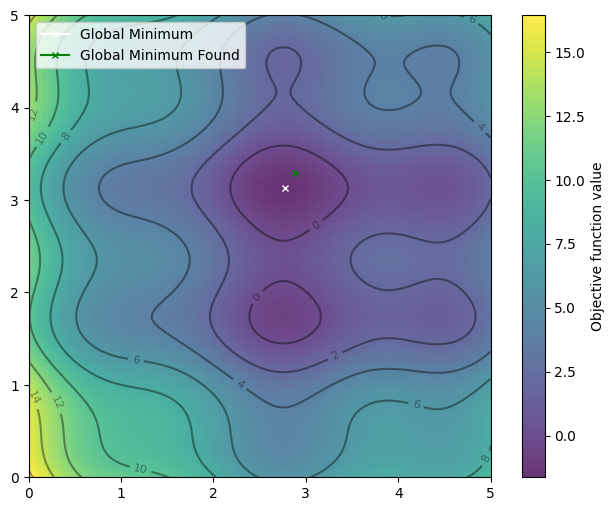

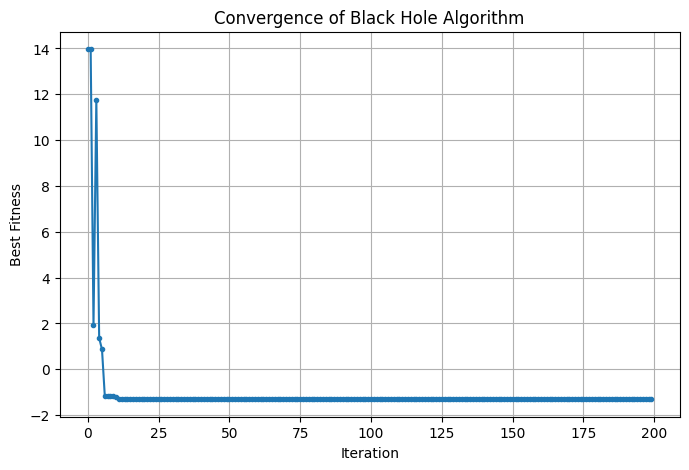

In [219]:
bha = BlackHoleAlgorithm(objective_func=f_1, n_stars=100, max_iter=200)
best_pos = bha.optimize()

x, y = np.array(np.meshgrid(np.linspace(0,5,100), np.linspace(0,5,100)))
z = f_1(x, y)
x_min = x.ravel()[np.argmin(z)]
y_min = y.ravel()[np.argmin(z)]

plt.figure(figsize=(8,6))
plt.imshow(z, extent=(0,5,0,5), origin='lower', cmap='viridis', alpha=0.8)
plt.colorbar(label='Objective function value')
plt.plot([x_min], [y_min], marker='x', markersize=5, color="white", label='Global Minimum')
plt.plot([best_pos[0]], [best_pos[1]], marker='x', markersize=5, color="green", label='Global Minimum Found')
contours = plt.contour(x, y, z, 10, colors='black', alpha=0.4)
plt.clabel(contours, inline=True, fontsize=8, fmt="%.0f")
plt.legend()
plt.show()

bha.plot_convergence()

# Otimizando função 2

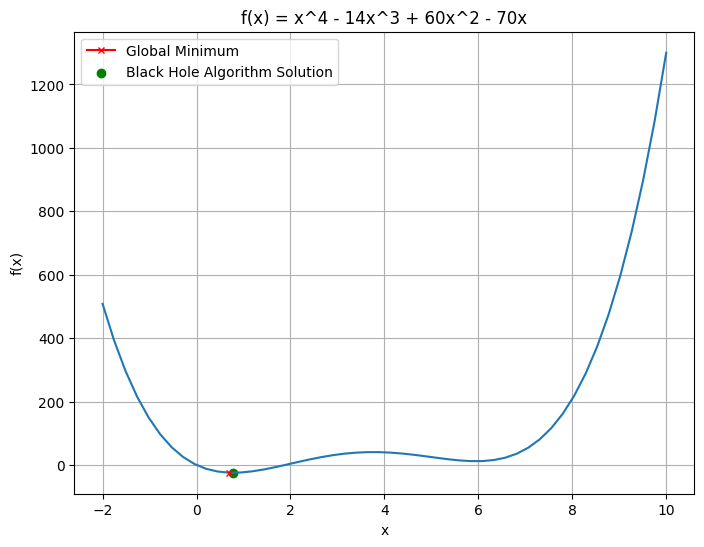

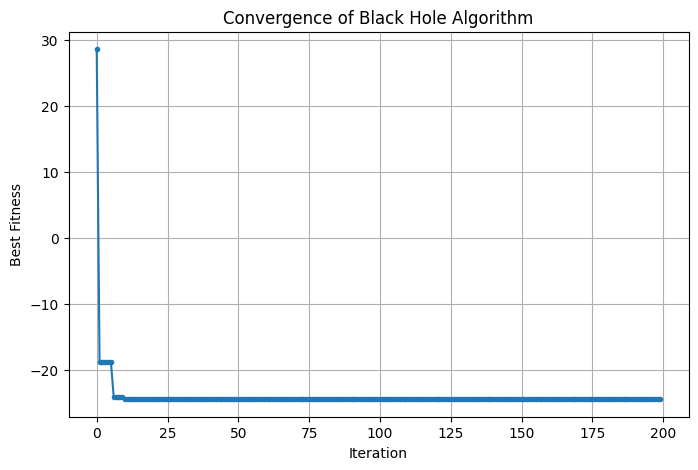

In [225]:
bha = BlackHoleAlgorithm(objective_func=f_2, n_stars=100, max_iter=200)
best_pos = bha.optimize()

xs = np.linspace(-2, 10, 50) # gera um array de 50 pontos entre -1 e 10
ys = f_2(xs)
x_min = xs[np.argmin(ys)]

plt.figure(figsize=(8,6))
plt.plot(xs, ys)
plt.plot([x_min], [f_2(x_min)], marker='x', markersize=5, color="red", label='Global Minimum')
plt.scatter(best_pos, f_2(best_pos), color='green', label='Black Hole Algorithm Solution')
plt.title("f(x) = x^4 - 14x^3 + 60x^2 - 70x")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()


bha.plot_convergence()

In [194]:
np.random.rand(1)

array([0.70171376])